In [ ]:
import pandas as pd

df = pd.read_csv("cardio_train.csv", sep=";")

print("="*50)
print("Data Dimensions Check:")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("="*50)

print("\nFirst 5 rows of the dataset:")
print(df.head())

Data Dimensions Check:
Number of rows: 70000
Number of columns: 13

First 5 rows of the dataset:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


In [ ]:
import numpy as np

df.drop(columns=['id'], inplace=True)

df['age'] = (df['age'] / 365.25).round().astype(int)

df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 220)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 130)]
df = df[df['ap_hi'] > df['ap_lo']]

print("="*50)
print("Data Dimensions After Cleaning:")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("="*50)

print("\nFirst 5 rows of the cleaned dataset:")
print(df.head())

Data Dimensions After Cleaning:
Number of rows: 68639
Number of columns: 12

First 5 rows of the cleaned dataset:
   age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  \
0   50       2     168    62.0    110     80            1     1      0     0   
1   55       1     156    85.0    140     90            3     1      0     0   
2   52       1     165    64.0    130     70            3     1      0     0   
3   48       2     169    82.0    150    100            1     1      0     0   
4   48       1     156    56.0    100     60            1     1      0     0   

   active  cardio  
0       1       0  
1       1       1  
2       0       1  
3       1       1  
4       0       0  


In [ ]:
df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)
df['BMI'] = df['BMI'].round(1)

print("="*50)
print("Data Dimensions After Feature Engineering:")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("="*50)

print("\nFirst 5 rows showing the new BMI column:")
print(df[['height', 'weight', 'BMI', 'cardio']].head())

Data Dimensions After Feature Engineering:
Number of rows: 68639
Number of columns: 13

First 5 rows showing the new BMI column:
   height  weight   BMI  cardio
0     168    62.0  22.0       0
1     156    85.0  34.9       1
2     165    64.0  23.5       1
3     169    82.0  28.7       1
4     156    56.0  23.0       0


/tmp/ipykernel_10458/3097528367.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cardio', data=df, palette='Set2')


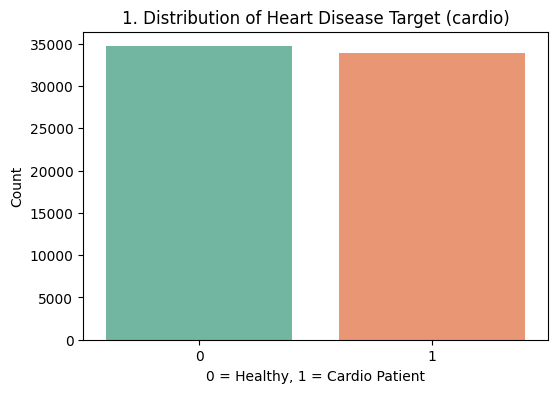

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='cardio', data=df, palette='Set2')
plt.title('1. Distribution of Heart Disease Target (cardio)')
plt.xlabel('0 = Healthy, 1 = Cardio Patient')
plt.ylabel('Count')
plt.show()

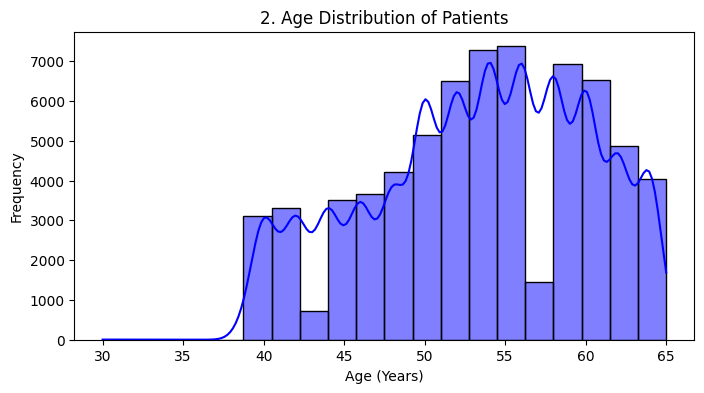

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(x='age', data=df, bins=20, kde=True, color='blue')
plt.title('2. Age Distribution of Patients')
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_10458/28955100.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cardio', y='BMI', data=df, palette='Set3')


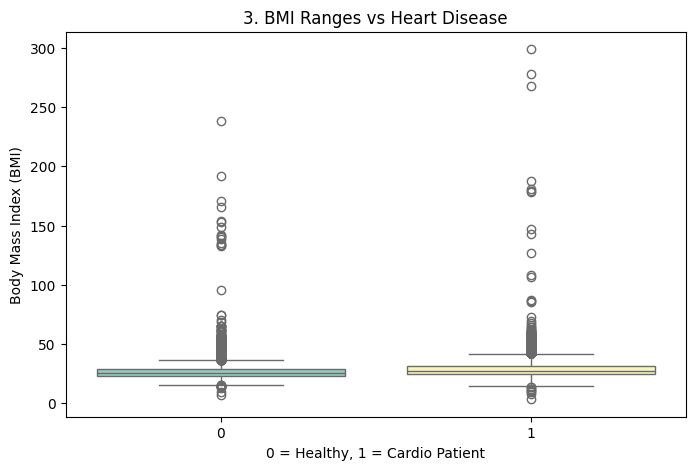

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='cardio', y='BMI', data=df, palette='Set3')
plt.title('3. BMI Ranges vs Heart Disease')
plt.xlabel('0 = Healthy, 1 = Cardio Patient')
plt.ylabel('Body Mass Index (BMI)')
plt.show()

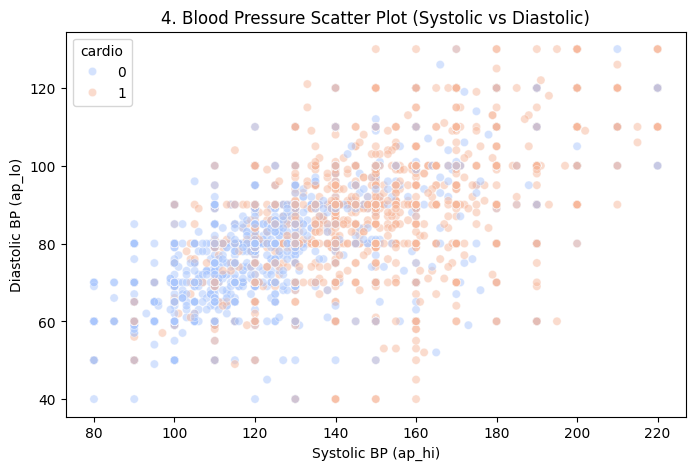

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='ap_hi', y='ap_lo', hue='cardio', data=df, alpha=0.5, palette='coolwarm')
plt.title('4. Blood Pressure Scatter Plot (Systolic vs Diastolic)')
plt.xlabel('Systolic BP (ap_hi)')
plt.ylabel('Diastolic BP (ap_lo)')
plt.show()

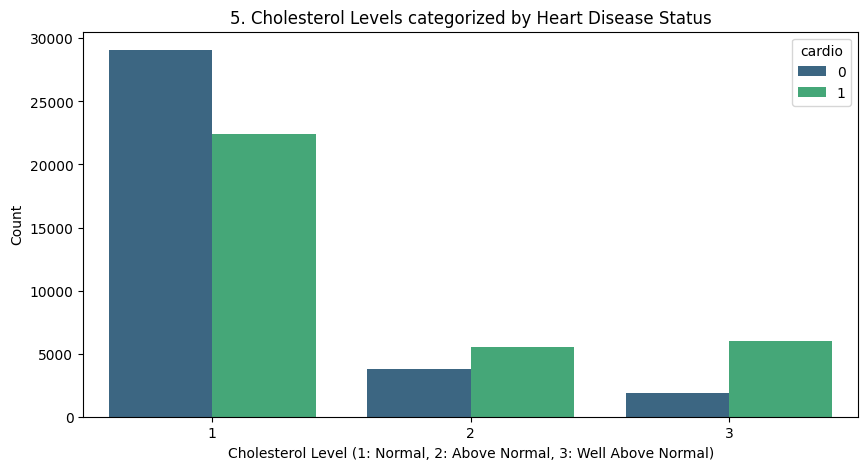

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x='cholesterol', hue='cardio', data=df, palette='viridis')
plt.title('5. Cholesterol Levels categorized by Heart Disease Status')
plt.xlabel('Cholesterol Level (1: Normal, 2: Above Normal, 3: Well Above Normal)')
plt.ylabel('Count')
plt.show()

In [ ]:
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')

X = df.drop(columns=['cardio'])
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)

dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("="*50)
print("Final Cleaned Model Results:")
print(f"1. Logistic Regression Accuracy : {lr_acc:.4f}")
print(f"2. Decision Tree Accuracy       : {dt_acc:.4f}")
print(f"3. Random Forest Accuracy       : {rf_acc:.4f}")
print("="*50)

Final Cleaned Model Results:
1. Logistic Regression Accuracy : 0.7284
2. Decision Tree Accuracy       : 0.7287
3. Random Forest Accuracy       : 0.7327


In [2]:
!pip install -q gradio

import gradio as gradio_pkg

def predict_heart_disease(age, gender, height, weight, ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active):
    gender_code = 1 if gender == "Female" else 2
    chol_code = 1 if cholesterol == "Normal" else (2 if cholesterol == "Above Normal" else 3)
    gluc_code = 1 if gluc == "Normal" else (2 if gluc == "Above Normal" else 3)
    smoke_code = 1 if smoke == "Yes" else 0
    alco_code = 1 if alco == "Yes" else 0
    active_code = 1 if active == "Yes" else 0

    bmi = round(weight / ((height / 100) ** 2), 1)

    input_data = [[age, gender_code, height, weight, ap_hi, ap_lo, chol_code, gluc_code, smoke_code, alco_code, active_code, bmi]]

    prediction = rf_model.predict(input_data)[0]

    if prediction == 1:
        return f"⚠️ Warning: High Risk of Cardiovascular Disease! (Calculated BMI: {bmi})"
    else:
        return f"✅ Good News: Patient is Healthy and at Low Risk. (Calculated BMI: {bmi})"

interface = gradio_pkg.Interface(
    fn=predict_heart_disease,
    inputs=[
        gradio_pkg.Slider(30, 80, value=50, label="Age (Years)"),
        gradio_pkg.Radio(["Female", "Male"], value="Female", label="Gender"),
        gradio_pkg.Slider(100, 220, value=165, label="Height (cm)"),
        gradio_pkg.Slider(30, 150, value=70, label="Weight (kg)"),
        gradio_pkg.Slider(80, 200, value=120, label="Systolic BP (ap_hi)"),
        gradio_pkg.Slider(40, 120, value=80, label="Diastolic BP (ap_lo)"),
        gradio_pkg.Radio(["Normal", "Above Normal", "Well Above Normal"], value="Normal", label="Cholesterol Level"),
        gradio_pkg.Radio(["Normal", "Above Normal", "Well Above Normal"], value="Normal", label="Glucose Level"),
        gradio_pkg.Radio(["Yes", "No"], value="No", label="Smoker?"),
        gradio_pkg.Radio(["Yes", "No"], value="No", label="Alcohol Consumer?"),
        gradio_pkg.Radio(["Yes", "No"], value="Yes", label="Physically Active?")
    ],
    outputs=gradio_pkg.Textbox(label="Prediction Result"),
    title="Real-Time Cardiovascular Disease Prediction System",
    description="Enter the patient's clinical and physical parameters to predict heart disease risk using the trained Random Forest Model."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e5aa317dbe8c6b3c04.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ Saved the winning Random Forest model as 'heart_disease_rf_model.pkl' successfully!



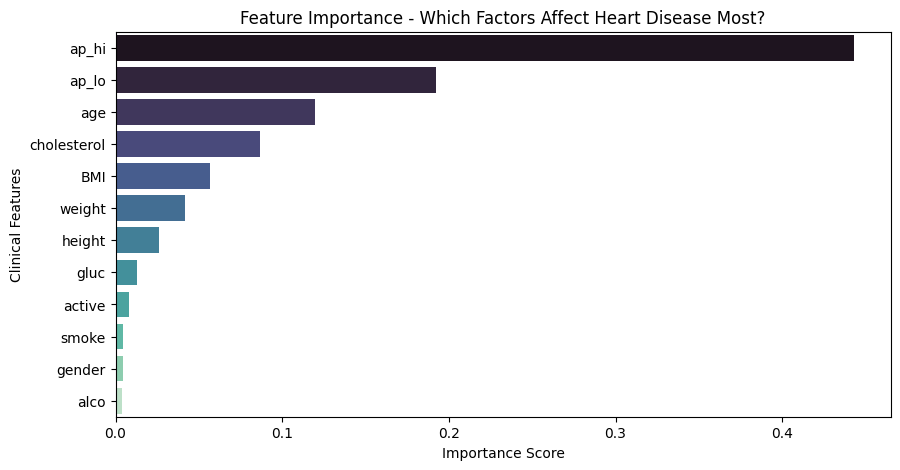

In [ ]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

joblib.dump(rf_model, 'heart_disease_rf_model.pkl')
print("✅ Saved the winning Random Forest model as 'heart_disease_rf_model.pkl' successfully!\n")

importances = rf_model.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='mako')
plt.title('Feature Importance - Which Factors Affect Heart Disease Most?')
plt.xlabel('Importance Score')
plt.ylabel('Clinical Features')
plt.show()

In [ ]:
app_code = """
import gradio as gr
import joblib

# Load the saved model
model = joblib.load('heart_disease_rf_model.pkl')

def predict_heart_disease(age, gender, height, weight, ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active):
    gender_code = 1 if gender == "Female" else 2
    chol_code = 1 if cholesterol == "Normal" else (2 if cholesterol == "Above Normal" else 3)
    gluc_code = 1 if gluc == "Normal" else (2 if gluc == "Above Normal" else 3)
    smoke_code = 1 if smoke == "Yes" else 0
    alco_code = 1 if alco == "Yes" else 0
    active_code = 1 if active == "Yes" else 0

    bmi = round(weight / ((height / 100) ** 2), 1)

    input_data = [[age, gender_code, height, weight, ap_hi, ap_lo, chol_code, gluc_code, smoke_code, alco_code, active_code, bmi]]
    prediction = model.predict(input_data)[0]

    if prediction == 1:
        return f"⚠️ Warning: High Risk of Cardiovascular Disease! (Calculated BMI: {bmi})"
    else:
        return f"✅ Good News: Patient is Healthy and at Low Risk. (Calculated BMI: {bmi})"

interface = gr.Interface(
    fn=predict_heart_disease,
    inputs=[
        gr.Slider(30, 80, value=50, label="Age (Years)"),
        gr.Radio(["Female", "Male"], value="Female", label="Gender"),
        gr.Slider(100, 220, value=165, label="Height (cm)"),
        gr.Slider(30, 150, value=70, label="Weight (kg)"),
        gr.Slider(80, 200, value=120, label="Systolic BP (ap_hi)"),
        gr.Slider(40, 120, value=80, label="Diastolic BP (ap_lo)"),
        gr.Radio(["Normal", "Above Normal", "Well Above Normal"], value="Normal", label="Cholesterol Level"),
        gr.Radio(["Normal", "Above Normal", "Well Above Normal"], value="Normal", label="Glucose Level"),
        gr.Radio(["Yes", "No"], value="No", label="Smoker?"),
        gr.Radio(["Yes", "No"], value="No", label="Alcohol Consumer?"),
        gr.Radio(["Yes", "No"], value="Yes", label="Physically Active?")
    ],
    outputs=gr.Textbox(label="Prediction Result"),
    title="Real-Time Cardiovascular Disease Prediction System",
    description="Cardiovascular Disease Prediction using Random Forest Model."
)

if __name__ == "__main__":
    interface.launch()
"""

with open("app.py", "w") as f:
    f.write(app_code.strip())
print("✅ app.py has been created successfully!")

✅ app.py has been created successfully!


In [ ]:
requirements_text = """
pandas==2.0.3
numpy==1.24.3
scikit-learn==1.2.2
matplotlib==3.7.1
seaborn==0.12.2
joblib==1.2.0
gradio==3.35.2
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_text.strip())
print("✅ 'requirements.txt' has been created successfully!")

✅ 'requirements.txt' has been created successfully!
